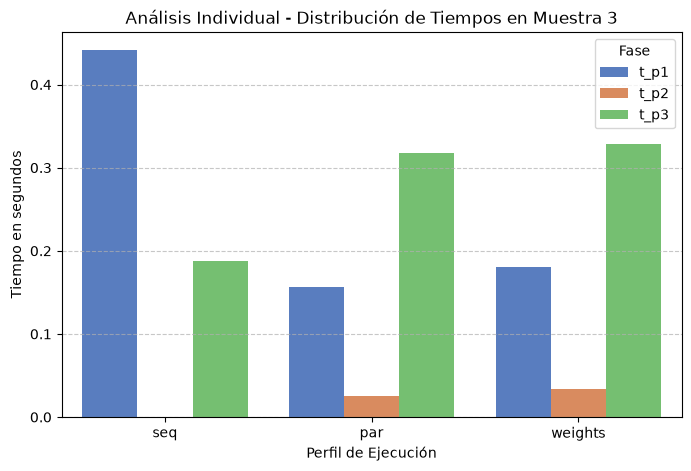

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("results/benchmark_granular_workflow.csv")

# 1. Elegimos una muestra específica para analizar (ej. Muestra 3)
sample_id = 3
df_sample = df[df['sample'] == sample_id]

# 2. Reestructurar datos para graficar las fases fácilmente
df_melted = df_sample.melt(
    id_vars=['perfil'], 
    value_vars=['t_p1', 't_p2', 't_p3'], 
    var_name='Fase', 
    value_name='Tiempo (s)'
)

# 3. Graficar
plt.figure(figsize=(8, 5))
sns.barplot(data=df_melted, x='perfil', y='Tiempo (s)', hue='Fase', palette='muted')
plt.title(f"Análisis Individual - Distribución de Tiempos en Muestra {sample_id}")
plt.ylabel("Tiempo en segundos")
plt.xlabel("Perfil de Ejecución")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

        SELECCIÓN DINÁMICA DE MUESTRA PARA ANÁLISIS FINO
🎯 Red de Máxima Complejidad Detectada: Muestra #1
📊 Cantidad de Campos Atractores (n_fields): 222912
🔗 Cantidad de Pares Compatibles (n_pairs): 192

💾 Gráfico analítico guardado exitosamente en: 'results/worst_case_sample_analysis.png'


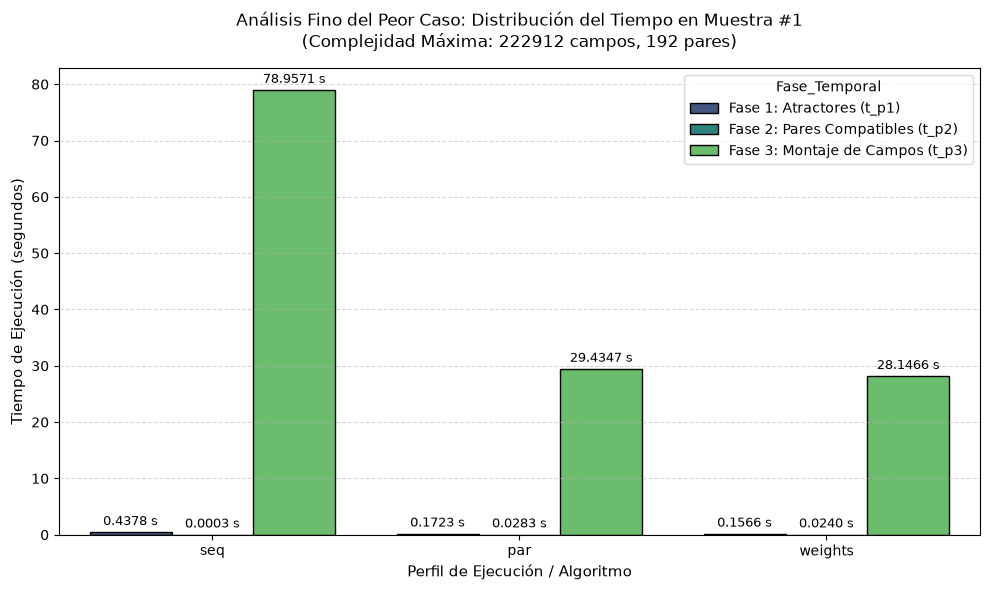

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el archivo de datos del benchmark
csv_path = "results/benchmark_granular_workflow.csv"
df = pd.read_csv(csv_path)

# 2. Identificar dinámicamente la muestra con la mayor cantidad de campos atractores
# Filtramos por un solo perfil (ej. 'seq') para no duplicar la búsqueda por muestra
df_unique_samples = df[df['perfil'] == 'seq']
idx_max_complexity = df_unique_samples['n_fields'].idxmax()

max_sample_id = int(df_unique_samples.loc[idx_max_complexity, 'sample'])
max_fields_count = int(df_unique_samples.loc[idx_max_complexity, 'n_fields'])
max_pairs_count = int(df_unique_samples.loc[idx_max_complexity, 'n_pairs'])

print("=" * 60)
print("        SELECCIÓN DINÁMICA DE MUESTRA PARA ANÁLISIS FINO")
print("=" * 60)
print(f"🎯 Red de Máxima Complejidad Detectada: Muestra #{max_sample_id}")
print(f"📊 Cantidad de Campos Atractores (n_fields): {max_fields_count}")
print(f"🔗 Cantidad de Pares Compatibles (n_pairs): {max_pairs_count}")
print("=" * 60)

# 3. Filtrar los datos de los 3 métodos pero ÚNICAMENTE para esa muestra ganadora
df_target_sample = df[df['sample'] == max_sample_id]

# 4. Reestructurar las fases (t_p1, t_p2, t_p3) a formato largo para Seaborn
df_melted = df_target_sample.melt(
    id_vars=['perfil'], 
    value_vars=['t_p1', 't_p2', 't_p3'], 
    var_name='Fase_Temporal', 
    value_name='Tiempo_Segundos'
)

# Mapeo estético para que el gráfico sea elegante y limpio
fases_labels = {
    't_p1': 'Fase 1: Atractores (t_p1)',
    't_p2': 'Fase 2: Pares Compatibles (t_p2)',
    't_p3': 'Fase 3: Montaje de Campos (t_p3)'
}
df_melted['Fase_Temporal'] = df_melted['Fase_Temporal'].map(fases_labels)

# 5. Generar el gráfico de comparación granular
plt.figure(figsize=(10, 6))

# Dibujar barras agrupadas por perfil y coloreadas por fase
ax = sns.barplot(
    data=df_melted, 
    x='perfil', 
    y='Tiempo_Segundos', 
    hue='Fase_Temporal', 
    palette='viridis',
    edgecolor='black'
)

# Configuración de etiquetas y títulos con rigor académico
plt.title(f"Análisis Fino del Peor Caso: Distribución del Tiempo en Muestra #{max_sample_id}\n(Complejidad Máxima: {max_fields_count} campos, {max_pairs_count} pares)", fontsize=12, pad=15)
plt.ylabel("Tiempo de Ejecución (segundos)", fontsize=11)
plt.xlabel("Perfil de Ejecución / Algoritmo", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Añadir los valores numéricos encima de las barras para una lectura inmediata
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f s', padding=3, fontsize=9)

plt.tight_layout()

# Guardar la gráfica en la carpeta de resultados
output_img = "results/worst_case_sample_analysis.png"
plt.savefig(output_img, dpi=300)
print(f"\n💾 Gráfico analítico guardado exitosamente en: '{output_img}'")
plt.show()